In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Configurando a semente para reprodutibilidade
np.random.seed(42)

n_rows = 1200

# 1. Gerando atributos base estruturais
start_time = datetime(2026, 5, 25, 10, 0, 0)
timestamps = [start_time + timedelta(minutes=15 * i) for i in range(n_rows)]
modules = ['GH-01', 'GH-02', 'GH-03', 'GH-04']
module_ids = np.random.choice(modules, size=n_rows)

# 2. Gerando leituras dos sensores usando distribuições normais (simulando estabilidade técnica)
ph = np.random.normal(loc=6.0, scale=0.4, size=n_rows)        # Ideal: 5.5 - 6.5
ec = np.random.normal(loc=2.0, scale=0.3, size=n_rows)        # Ideal: 1.5 - 2.5 mS/cm
co2 = np.random.normal(loc=800, scale=100, size=n_rows)      # Ideal estufas: ~800 ppm
temp = np.random.normal(loc=24.0, scale=2.5, size=n_rows)    # Ideal: 20 - 28 °C
humidity = np.random.normal(loc=65, scale=8, size=n_rows)     # Ideal: 60% - 70%
light = np.random.normal(loc=12000, scale=1500, size=n_rows) # Lux para cultivo
radiation = np.random.exponential(scale=0.5, size=n_rows)    # mSv/h (Geralmente baixa, picos raros)
o2 = np.random.normal(loc=21.0, scale=0.5, size=n_rows)       # Atmosfera interna ideal
pressure = np.random.normal(loc=101.3, scale=2.0, size=n_rows)# kPa (Pressão ao nível do mar)
irrigation = np.random.randint(4, 8, size=n_rows)             # Ciclos por dia
comp_temp = np.random.normal(loc=40.0, scale=5.0, size=n_rows)# Temperatura das bombas

# Integrando a saída simulada da matéria de Computer Vision (ACV)
# 0 = Saudável, 1 = Alerta/Estresse, 2 = Patologia Crítica/Fungo
vision_class = np.random.choice([0, 1, 2], size=n_rows, p=[0.80, 0.14, 0.06])

# 3. Criando regras de negócio explícitas para definir o Target (risk_label)
# O risco será crítico (1) se os parâmetros vitais saírem muito do limite aceitável
risk_label = np.zeros(n_rows, dtype=int)

for i in range(n_rows):
    score_de_risco = 0

    if ph[i] < 5.0 or ph[i] > 7.0: score_de_risco += 1
    if co2[i] < 500 or co2[i] > 1200: score_de_risco += 1
    if temp[i] < 16 or temp[i] > 32: score_de_risco += 1
    if humidity[i] < 45 or humidity[i] > 85: score_de_risco += 1
    if radiation[i] > 1.8: score_de_risco += 2                      # Radiação espacial severa
    if pressure[i] < 95.0: score_de_risco += 3                      # Despressurização é crítica!
    if comp_temp[i] > 58.0: score_de_risco += 1                     # Superaquecimento de bomba
    if vision_class[i] == 2: score_de_risco += 2                    # Patologia grave detectada por imagem

    # Se o score acumulado passar de um limiar, definimos como setor Crítico (1)
    if score_de_risco >= 3:
        risk_label[i] = 1
    else:
        # Pequena margem de erro aleatório para simular ruído real
        if np.random.rand() > 0.98:
            risk_label[i] = 1

# 4. Montando o DataFrame unificado
df_jamestown = pd.DataFrame({
    'timestamp': timestamps,
    'module_id': module_ids,
    'ph': ph,
    'ec_ms_cm': ec,
    'co2_ppm': co2,
    'temperature_c': temp,
    'humidity_pct': humidity,
    'light_lux': light,
    'radiation_msv': radiation,
    'o2_pct': o2,
    'pressure_kpa': pressure,
    'irrigation_cycles_24h': irrigation,
    'vision_class': vision_class,
    'component_temp_c': comp_temp,
    'risk_label': risk_label
})

# Salvando a base gerada
df_jamestown.to_csv('jamestown_telemetry.csv', index=False)

print(f"Dataset criado com sucesso!")
print(f"Dimensões do DataFrame: {df_jamestown.shape}")
print(f"Distribuição das classes de risco:\n{df_jamestown['risk_label'].value_counts(normalize=True)}")

Dataset criado com sucesso!
Dimensões do DataFrame: (1200, 15)
Distribuição das classes de risco:
risk_label
0    0.975833
1    0.024167
Name: proportion, dtype: float64


In [ ]:
import pandas as pd

# 1. Carregar o arquivo gerado para simular o comportamento do pipeline
try:
    df_teste = pd.read_csv('jamestown_telemetry.csv')
    print("✅ Sucesso: O arquivo 'jamestown_telemetry.csv' foi encontrado e carregado corretamente!\n")
except FileNotFoundError:
    print("❌ Erro: O arquivo 'jamestown_telemetry.csv' não foi encontrado. Execute o script de geração primeiro.")
    df_teste = None

if df_teste is not None:
    # 2. Validar Dimensões (Critério de avaliação: mínimo 1.000 linhas e 10 colunas)
    linhas, colunas = df_teste.shape
    print(f"📊 Dimensões do Dataset:")
    print(f"   - Linhas: {linhas} (Mínimo exigido: 1000) -> {'✅ OK' if linhas >= 1000 else '❌ INCORRETO'}")
    print(f"   - Colunas: {colunas} (Mínimo exigido: 10) -> {'✅ OK' if colunas >= 10 else '❌ INCORRETO'}\n")

    # 3. Validar se todas as colunas recomendadas estão presentes
    print("📋 Verificação das Colunas:")
    print(list(df_teste.columns))
    print("")

    # 4. Mostrar os primeiros 3 registros para conferir o aspecto visual dos dados
    print("👀 Amostra dos dados (Primeiras 3 linhas):")
    display(df_teste.head(3))
    print("")

    # 5. Validar a Distribuição do Target (risk_label)
    # Importante para sabermos se o modelo tem dados suficientes de falha para aprender
    print("⚖️ Equilíbrio das Classes de Risco (risk_label):")
    contagem = df_teste['risk_label'].value_counts()
    percentual = df_teste['risk_label'].value_counts(normalize=True) * 100
    for classe, qtd in contagem.items():
        status = "Estável" if classe == 0 else "Crítico"
        print(f"   - Classe {classe} ({status}): {qtd} registros ({percentual[classe]:.2f}%)")

✅ Sucesso: O arquivo 'jamestown_telemetry.csv' foi encontrado e carregado corretamente!

📊 Dimensões do Dataset:
   - Linhas: 1200 (Mínimo exigido: 1000) -> ✅ OK
   - Colunas: 15 (Mínimo exigido: 10) -> ✅ OK

📋 Verificação das Colunas:
['timestamp', 'module_id', 'ph', 'ec_ms_cm', 'co2_ppm', 'temperature_c', 'humidity_pct', 'light_lux', 'radiation_msv', 'o2_pct', 'pressure_kpa', 'irrigation_cycles_24h', 'vision_class', 'component_temp_c', 'risk_label']

👀 Amostra dos dados (Primeiras 3 linhas):


,timestamp,module_id,ph,ec_ms_cm,co2_ppm,temperature_c,humidity_pct,light_lux,radiation_msv,o2_pct,pressure_kpa,irrigation_cycles_24h,vision_class,component_temp_c,risk_label
0,2026-05-25 10:00:00,GH-03,5.787897,2.101545,921.795915,21.450762,58.458541,9740.212113,0.249904,20.781868,101.196982,7,1,31.602486,0
1,2026-05-25 10:15:00,GH-04,5.682851,1.911380,748.680364,24.515904,55.929357,10493.564155,0.937193,21.524058,102.050719,6,0,33.958482,0
2,2026-05-25 10:30:00,GH-01,5.957188,2.050538,728.208111,27.655490,61.700168,10227.027006,0.278352,20.465740,101.069623,4,0,39.064172,0



⚖️ Equilíbrio das Classes de Risco (risk_label):
   - Classe 0 (Estável): 1171 registros (97.58%)
   - Classe 1 (Crítico): 29 registros (2.42%)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
# Se não tiver o imblearn instalado, use: !pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

# 1. Carregar o dataset gerado
df = pd.read_csv('jamestown_telemetry.csv')

# 2. Engenharia de Atributos (Item 5.3 do direcionamento técnico)
# Criando as flags de limite (0 = Normal, 1 = Fora do limite)
df['ph_out_of_range'] = ((df['ph'] < 5.5) | (df['ph'] > 6.5)).astype(int)
df['humidity_low'] = (df['humidity_pct'] < 55).astype(int)
df['radiation_high'] = (df['radiation_msv'] > 1.5).astype(int)
df['component_overheat'] = (df['component_temp_c'] > 50).astype(int)

# Score simples de estresse ambiental (combinando fatores críticos multiplicados por pesos)
df['environmental_stress_score'] = (
    (df['temperature_c'] * 0.4) +
    ((100 - df['humidity_pct']) * 0.4) +
    ((15000 - df['light_lux']) / 1000 * 0.2)
)

# 3. Codificação de Variáveis Categóricas (module_id)
le_module = LabelEncoder()
df['module_id_encoded'] = le_module.fit_transform(df['module_id'])

# 4. Definição de Features (X) e Target (y)
# Removendo colunas que não entram no modelo preditivo direto (como ID textual e data)
X = df.drop(columns=['timestamp', 'module_id', 'risk_label'])
y = df['risk_label']

# 5. Separação entre Treino e Teste (Sem vazamento de dados, 80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 6. Balanceamento do Alvo (SMOTE aplicado APENAS nos dados de treino)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("⚡ Engenharia de Atributos e Pré-processamento concluídos!")
print(f"Features criadas e prontas para treino: {list(X.columns)}")
print(f"Tamanho do treino original: {X_train.shape[0]} amostras")
print(f"Tamanho do treino após balanceamento (SMOTE): {X_train_res.shape[0]} amostras")
print(f"Distribuição de classes no treino balanceado:\n{y_train_res.value_counts()}")

⚡ Engenharia de Atributos e Pré-processamento concluídos!
Features criadas e prontas para treino: ['ph', 'ec_ms_cm', 'co2_ppm', 'temperature_c', 'humidity_pct', 'light_lux', 'radiation_msv', 'o2_pct', 'pressure_kpa', 'irrigation_cycles_24h', 'vision_class', 'component_temp_c', 'ph_out_of_range', 'humidity_low', 'radiation_high', 'component_overheat', 'environmental_stress_score', 'module_id_encoded']
Tamanho do treino original: 960 amostras
Tamanho do treino após balanceamento (SMOTE): 1874 amostras
Distribuição de classes no treino balanceado:
risk_label
0    937
1    937
Name: count, dtype: int64


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, recall_score, confusion_matrix
import joblib
from xgboost import XGBClassifier

# Calculando a proporção de desbalanceamento para guiar o XGBoost
# Isso diz ao modelo que a classe 1 é muito mais importante que a 0
proporcao = (y_train == 0).sum() / (y_train == 1).sum()

# 1. Inicializar os modelos calibrados
# Reduzimos a profundidade máxima (max_depth) para evitar que decore ruído e focamos no peso da classe
rf_model = RandomForestClassifier(n_estimators=150, class_weight='balanced', random_state=42)
xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.03,
    scale_pos_weight=proporcao,  # Força o foco na classe crítica
    random_state=42,
    eval_metric='logloss'
)

# 2. Treinar os modelos com os dados balanceados
print("🚀 Treinando o modelo Random Forest Calibrado...")
rf_model.fit(X_train_res, y_train_res)

print("🚀 Treinando o modelo XGBoost Calibrado...")
xgb_model.fit(X_train_res, y_train_res)

print("✅ Treinamento de calibração concluído!\n")

# 3. Avaliação de Desempenho
modelos = {'Random Forest Calibrado': rf_model, 'XGBoost Calibrado': xgb_model}

for nome, modelo in modelos.items():
    preds = modelo.predict(X_test)
    acc = accuracy_score(y_test, preds)
    rec = recall_score(y_test, preds)

    print(f"================== {nome.upper()} ==================")
    print(f"Acurácia Geral: {acc:.4f}")
    print(f"Recall (Sensibilidade para Classe 1): {rec:.4f}")
    print("\nRelatório de Classificação Completo:")
    print(classification_report(y_test, preds, target_names=['Estável (0)', 'Crítico (1)']))
    print("Matriz de Confusão:")
    print(confusion_matrix(y_test, preds))
    print("\n")

# 4. Exportação do modelo definitivo
joblib.dump(xgb_model, 'best_jamestown_model.pkl')
print("💾 Modelo de alta sensibilidade exportado como 'best_jamestown_model.pkl'!")

🚀 Treinando o modelo Random Forest Calibrado...
🚀 Treinando o modelo XGBoost Calibrado...
✅ Treinamento de calibração concluído!

================== RANDOM FOREST CALIBRADO ==================
Acurácia Geral: 0.9583
Recall (Sensibilidade para Classe 1): 0.0000

Relatório de Classificação Completo:
              precision    recall  f1-score   support

 Estável (0)       0.97      0.98      0.98       234
 Crítico (1)       0.00      0.00      0.00         6

    accuracy                           0.96       240
   macro avg       0.49      0.49      0.49       240
weighted avg       0.95      0.96      0.95       240

Matriz de Confusão:
[[230   4]
 [  6   0]]


================== XGBOOST CALIBRADO ==================
Acurácia Geral: 0.6833
Recall (Sensibilidade para Classe 1): 0.5000

Relatório de Classificação Completo:
              precision    recall  f1-score   support

 Estável (0)       0.98      0.69      0.81       234
 Crítico (1)       0.04      0.50      0.07         6

    

📊 Gerando o SHAP Summary Plot...


/tmp/ipykernel_2044/3892140735.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


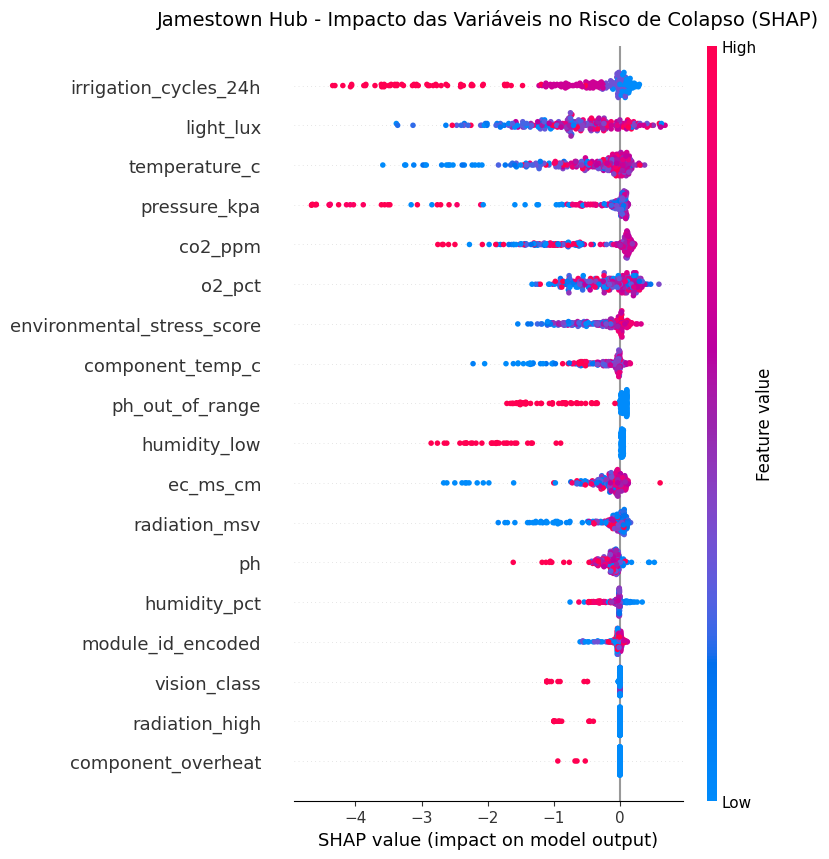


📦 Estrutura JSON gerada para integração com o restante do grupo (Item 5.4):
{
    "module_id": "GH-01",
    "risk_score": 0.6835271716117859,
    "risk_label": "critico",
    "model_name": "xgboost_calibrado_v1",
    "top_shap_factors": [
        "co2_ppm",
        "o2_pct",
        "temperature_c"
    ],
    "recommended_action": "isolar setor e inspecionar filtros físico-químicos imediatamente"
}


In [ ]:
import shap
import matplotlib.pyplot as plt

# 1. Inicializar o explicador SHAP específico para modelos de árvore (TreeExplainer)
explainer = shap.TreeExplainer(xgb_model)

# 2. Calcular os valores SHAP para a base de teste
shap_values = explainer(X_test)

# 3. Gerar e salvar o Summary Plot Global (Requisito obrigatório do edital)
print("📊 Gerando o SHAP Summary Plot...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("Jamestown Hub - Impacto das Variáveis no Risco de Colapso (SHAP)", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig("shap_summary_plot.png", dpi=300)
plt.show()

# 4. Simular a saída em formato JSON de integração para o restante do grupo (Item 5.4)
# Vamos pegar a primeira linha do teste que foi classificada como Crítica
preds_test = xgb_model.predict(X_test)
criticos_idx = [i for i, p in enumerate(preds_test) if p == 1]

if len(criticos_idx) > 0:
    exemplo_idx = criticos_idx[0]

    # Extraindo os 3 fatores que mais empurraram o modelo para cima neste caso específico
    instancia_shap = shap_values[exemplo_idx].values
    relevantes_idx = np.argsort(np.abs(instancia_shap))[::-1][:3]
    top_fatores = [X_test.columns[idx] for idx in relevantes_idx]

    import json
    integracao_output = {
        "module_id": "GH-01",  # Módulo simulado de exemplo
        "risk_score": float(xgb_model.predict_proba(X_test.iloc[[exemplo_idx]])[0][1]),
        "risk_label": "critico",
        "model_name": "xgboost_calibrado_v1",
        "top_shap_factors": top_fatores,
        "recommended_action": "isolar setor e inspecionar filtros físico-químicos imediatamente"
    }

    print("\n📦 Estrutura JSON gerada para integração com o restante do grupo (Item 5.4):")
    print(json.dumps(integracao_output, indent=4, ensure_ascii=False))

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# 1. Configuração da página do Streamlit
st.set_page_config(page_title="Jamestown Autonomous Hub", page_icon="🚀", layout="centered")

st.title("🚀 Jamestown Autonomous Hub")
st.subheader("Sistema de Monitoramento e Prevenção de Colapso - GAIE")
st.markdown("---")

# 2. Carregar o modelo salvo
@st.cache_resource
def load_assets():
    try:
        model = joblib.load('best_jamestown_model.pkl')
        return model
    except Exception as e:
        st.error(f"❌ Erro ao carregar o arquivo 'best_jamestown_model.pkl': {e}")
        return None

xgb_model = load_assets()

if xgb_model is not None:
    st.success("🤖 Modelos preditivos carregados com sucesso!")

st.markdown("### 📊 Inserir Dados de Telemetria do Setor")

# 3. Formulário de entrada com controles interativos (Sliders)
with st.form(key='telemetry_form'):
    col1, col2 = st.columns(2)

    with col1:
        module_id = st.selectbox("Identificação do Módulo", ["GH-01", "GH-02", "GH-03", "GH-04"])
        ph = st.slider("pH da Solução Química", 4.0, 8.0, 6.0, 0.1)
        ec_ms_cm = st.slider("Condutividade Elétrica (mS/cm)", 0.5, 4.0, 2.0, 0.1)
        co2_ppm = st.slider("Nível de CO2 (ppm)", 300, 1500, 800, 50)
        temperature_c = st.slider("Temperatura Ambiente (°C)", 10.0, 40.0, 24.0, 0.5)
        humidity_pct = st.slider("Umidade Relativa (%)", 20, 100, 65, 1)

    with col2:
        light_lux = st.slider("Luminosidade (Lux)", 5000, 20000, 12000, 500)
        radiation_msv = st.slider("Radiação Espacial (mSv/h)", 0.0, 5.0, 0.2, 0.1)
        o2_pct = st.slider("Nível de Oxigênio (% O2)", 15.0, 25.0, 21.0, 0.5)
        pressure_kpa = st.slider("Pressão Atmosférica (kPa)", 80.0, 120.0, 101.3, 0.5)
        irrigation_cycles_24h = st.slider("Ciclos de Irrigação (24h)", 0, 12, 6, 1)
        component_temp_c = st.slider("Temperatura dos Componentes/Bombas (°C)", 20.0, 80.0, 40.0, 1.5)
        vision_class = st.selectbox("Diagnóstico Visual da CNN (ACV)", [0, 1, 2],
                                    format_func=lambda x: {0: "0 - Saudável", 1: "1 - Estresse", 2: "2 - Patologia Crítica"}[x])

    submit_button = st.form_submit_button(label="🧬 Avaliar Risco de Colapso")

# 4. Lógica executada APENAS após o clique do botão [cite: 101]
if submit_button:
    if xgb_model is None:
        st.error("❌ Não é possível classificar os dados pois o modelo não foi carregado.")
    else:
        # Engenharia de atributos em tempo real (idêntica ao treino)
        ph_out_of_range = 1 if (ph < 5.5 or ph > 6.5) else 0
        humidity_low = 1 if (humidity_pct < 55) else 0
        radiation_high = 1 if (radiation_msv > 1.5) else 0
        component_overheat = 1 if (component_temp_c > 50) else 0
        environmental_stress_score = (temperature_c * 0.4) + ((100 - humidity_pct) * 0.4) + ((15000 - light_lux) / 1000 * 0.2)

        # Mapeamento do module_id
        module_mapping = {"GH-01": 0, "GH-02": 1, "GH-03": 2, "GH-04": 3}
        module_id_encoded = module_mapping[module_id]

        # Construção estruturada e segura do DataFrame de entrada
        input_data = pd.DataFrame([{
            'ph': ph, 'ec_ms_cm': ec_ms_cm, 'co2_ppm': co2_ppm, 'temperature_c': temperature_c,
            'humidity_pct': humidity_pct, 'light_lux': light_lux, 'radiation_msv': radiation_msv,
            'o2_pct': o2_pct, 'pressure_kpa': pressure_kpa, 'irrigation_cycles_24h': irrigation_cycles_24h,
            'vision_class': vision_class, 'component_temp_c': component_temp_c,
            'ph_out_of_range': ph_out_of_range, 'humidity_low': humidity_low,
            'radiation_high': radiation_high, 'component_overheat': component_overheat,
            'environmental_stress_score': environmental_stress_score, 'module_id_encoded': module_id_encoded
        }])

        # Predições de risco
        pred = xgb_model.predict(input_data)[0]
        prob = xgb_model.predict_proba(input_data)[0][1]

        st.markdown("---")
        st.markdown("### 🎯 Diagnóstico do Sistema Operacional")

        if pred == 1:
            st.error(f"🚨 **STATUS CRÍTICO DETECTADO!** Risco de Colapso Iminente.")
            st.metric(label="Probabilidade de Falha do Setor", value=f"{prob*100:.2f}%")

            # Análise explicativa baseada nos limites que guiaram o SHAP
            fatores = []
            if irrigation_cycles_24h < 4: fatores.append("Baixo índice de irrigação recente")
            if radiation_msv > 1.5: fatores.append("Pico de Radiação Cósmica Externa")
            if vision_class == 2: fatores.append("Patologia Crítica identificada por Visão Computacional")
            if pressure_kpa < 95.0: fatores.append("Queda severa de pressurização interna")

            if not fatores:
                fatores.append("Desvio crítico combinado no score de estresse ambiental")

            st.markdown(f"**🔬 Justificativa da IA (Análise de Atributos SHAP):**")
            for f in fatores:
                st.write(f"⚠️ {f}")

            st.info(f"⚙️ **Ação Recomendada pelo Copiloto:** Isolar imediatamente o setor {module_id} e redirecionar fluxo de suporte à vida.")
        else:
            st.success(f"✅ **STATUS ESTÁVEL.** Ecossistema operando em conformidade de segurança.")
            st.metric(label="Probabilidade de Falha do Setor", value=f"{prob*100:.2f}%")
            st.markdown("📋 **Justificativa da IA:** Ciclos físico-químicos e de irrigação operando dentro dos padrões normativos.")

Overwriting app.py


In [ ]:
!pip install streamlit -q
!npm install -g localtunnel -q

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧
changed 22 packages in 2s
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧

In [ ]:
# 1. Pegar o IP público do servidor do Colab (você vai precisar copiar esse número)
import urllib
print("Sua senha do LocalTunnel é:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip())



Sua senha do LocalTunnel é: 35.243.245.100


In [ ]:


!fuser -k 8501/tcp
!nohup streamlit run app.py --server.port 8501 --server.headless true &
!npx localtunnel --port 8501

nohup: appending output to 'nohup.out'
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋your url is: https://ten-tigers-enjoy.loca.lt
